# Computing Multi-messenger improvement

Here is the overall structure of this notebook
1. Setup - imports, paths, configuration
2. Load data - load GW configuration and EM catalogue
3. EM parameter estimation - only for one target which we will pick as the source
4. GW parameter estimation - on all three targets that will be considered as candidates
5. Build physical priors - construct population distributions for lens parameters, distance, and time-delay scale
6. Prepare posterior samples - retain the relevant GW parameters and evaluate prior densities
7. Combine EM candidates - Evaluate each candidate's EM posterior over the GW samples and marginalize over the catalogue
8. Catalogue completeness
9. Calculate evidence gain

## Step 1 setup

In [1]:
import os

os.environ.setdefault("XLA_FLAGS", "--xla_force_host_platform_device_count=12")
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
for parent in [repo_root, *repo_root.parents]:
    src = parent / "src"
    if (src / "gwemfish").is_dir():
        sys.path.insert(0, str(src))
        break

import matplotlib.pyplot as plt

from gwemfish.simple_pipeline import (
    _deep_merge_dict,
    make_default_cfg,
    plot_system_observation,
    setup_em_observation,
    setup_gw_observation,
    run_inference, 
    plot_posterior, 
    to_source_plane_samples, 
    plot_source_posterior,
)

#
#OUTPUT_DIR = os.path.join("examples", "outputs", "simple_pipeline_demonstration")
#os.makedirs(OUTPUT_DIR, exist_ok=True)
#print("OUTPUT_DIR:", os.path.abspath(OUTPUT_DIR))

In [3]:
from gwemfish.config import DEFAULT_KWARGS_NUMERICS, SOLVER_PARAMS
OUTPUT_DIR = "figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

from scipy.stats import norm, uniform, gaussian_kde
from scipy.special import logsumexp

In [5]:
sample_cfg = {
    "em": {
        "pixel_grid_kwargs": {"npix": int(40), "pix_scl": 0.1},
        "psf_kwargs": {"psf_type": "GAUSSIAN", "fwhm": 0.16, "pixel_size": 0.1},#0.067
        "noise_simu_kwargs": {"npix": int(40), "background_rms": 1e-2, "exposure_time": 2200},
        "noise_inf_kwargs": {"npix": int(40), "background_rms": None, "exposure_time": 2200},
        "kwargs_numerics": DEFAULT_KWARGS_NUMERICS,
        "exposure_time": 2200,
        "seed": 87651,
        "source_pos": (0.0, 0.0), #Is this the position of the source of the GW or the position of the center of the source galaxy?
        "kwargs_source": [
            {
                "amp": 250,
                "R_sersic": 0.4,
                "n_sersic": 4.0,
                "e1": 0,
                "e2": 0,
                "center_x": 0.0, #same question for these center_x and y values
                "center_y": 0.0,
            }
        ],
        "kwargs_lens_light": [
            {
                "amp": 50.0,
                "R_sersic": 2.0,
                "n_sersic": 4.0,
                "e1": 0.0,
                "e2": 0.0,
                "center_x": 0.0,
                "center_y": 0.0,
            }
        ],
    },
    "lens": {
        "lens_model_list": ["EPL", "SHEAR"],
        "kwargs_lens": [
            {
                "theta_E": 1.2,
                "e1": 0.0,
                "e2": 0.1,
                "gamma": 2.0,
                "center_x": 0.0,
                "center_y": 0.0,
            },
            {"gamma1": 0.1, "gamma2": 0.0, "ra_0": 0.0, "dec_0": 0.0},
        ],
        "zl": 0.7,
        "zs": 1.5,
    },
    "gw": {
        "source_pos": (0.0, 0.0),
        "solver_params": SOLVER_PARAMS,
        "image_box_half_width": 10.6,
        "error_scales": {
            "sigma_td": 0.05,
            "sigma_dL_eff": 3.0,
            "epsilon": 0.005,
        },
    },
    "plot": {"plot_mode": "groupwise", "save_path": None, "save_tag": None, "hist_kwargs": {"density": True}},
    "source_plane": {"filter_std": None, "use_filtered": False},
    "output": {
        "output_dir": OUTPUT_DIR,
        "save_samples_path": None,
        "save_truths_path": None,
        "save_source_samples_path": None,
        "save_system_plot_path": None,
        "json_path": None,
    },
}

In [6]:
from lenstronomy.Util import param_util
from lenstronomy.SimulationAPI.mag_amp_conversion import MagAmpConversion

In [7]:
import copy

def row_to_cfg(row, sample_cfg, gw_enabled):
    """
    Convert one row of the Qiuhan's sky catalog into a GWEMFISH configuration.

    Parameters
    ----------
    row : pandas.Series
        One row of the lens catalog.

    sample_cfg : dict
        Reference GWEMFISH config.

    Returns
    -------
    cfg : dict
        GWEMFISH configuration for this lens system.
    """

    cfg = copy.deepcopy(sample_cfg)

    # ==========================================================
    # Convert axis ratio + PA -> ellipticity
    # ==========================================================

    # --- 1. PREPARE LENS (DEFLECTOR) LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    lens_e1, lens_e2 = param_util.phi_q2_ellipticity(phi=row['deflector_pa'], q=row['deflector_q'])


    kwargs_lens_light_mag = [{
    'magnitude': row['deflector_app_mag_VIS'],
    'R_sersic': row['deflector_Re'],
    'n_sersic': 4.0,  # Standard assumption for elliptical lens galaxies
    'e1': lens_e1, 'e2': lens_e2,
    'center_x': 0, 'center_y': 0
    }]

    # --- 2. PREPARE SOURCE LIGHT PARAMETERS ---
    # Convert q and pa to lenstronomy ellipticity (e1, e2)
    source_e1, source_e2 = param_util.phi_q2_ellipticity(phi=row['source_pa'], q=row['source_q'])
    
    # Choose your band (e.g., VIS)
    kwargs_source_mag = [{
        'magnitude': row['source_app_mag_VIS'], 
        'R_sersic': row['source_Re'],
        'n_sersic': row['source_sersic_index'],
        'e1': source_e1, 'e2': source_e2,
        'center_x': row['source_relative_x'], 
        'center_y': row['source_relative_y']
    }]
    
    # --- 3. CONVERT BOTH TO AMP ---
    # Define your model profile types
    kwargs_model = {
        'lens_light_model_list': ['SERSIC_ELLIPSE'],
        'source_light_model_list': ['SERSIC_ELLIPSE']
    }
    
    # Initialize the converter with your survey zero-point
    mag_converter = MagAmpConversion(kwargs_model=kwargs_model, magnitude_zero_point=25.9)
    
    # Get the final dictionaries containing the calculated 'amp' keys
    lens_light_amp = mag_converter.magnitude2amplitude(kwargs_lens_light_mag=kwargs_lens_light_mag)
    source_amp = mag_converter.magnitude2amplitude(kwargs_source_mag=kwargs_source_mag)
    
    #print(lens_light_amp)
    #print(source_amp)
    
    #source_e1, source_e2 = q_pa_to_e1e2(
     #   row["source_q"],
      #  row["source_pa"],
   # )

    lens_pos = (float(row['deflector_ra']), float(row['deflector_dec']))
    
    source_pos = (float(row["source_relative_x"]), float(row["source_relative_y"]))

    # ==========================================================
    # Lens geometry
    # ==========================================================

    cfg["lens"]["zl"] = float(row["deflector_z"])
    cfg["lens"]["zs"] = float(row["source_z"])

    # ==========================================================
    # Lens mass model (EPL)
    # ==========================================================

    cfg["lens"]["kwargs_lens"][0]["theta_E"] = float(row["deflector_thetaE"])
    cfg["lens"]["kwargs_lens"][0]["gamma"] = float(row["deflector_slope"])

    cfg["lens"]["kwargs_lens"][0]["e1"] = float(lens_e1)
    cfg["lens"]["kwargs_lens"][0]["e2"] = float(lens_e2)

    cfg["lens"]["kwargs_lens"][0]["center_x"] = 0.00
    cfg["lens"]["kwargs_lens"][0]["center_y"] = 0.00

    # ==========================================================
    # External shear
    # ==========================================================

    cfg["lens"]["kwargs_lens"][1]["gamma1"] = float(row["deflector_shear1"])
    cfg["lens"]["kwargs_lens"][1]["gamma2"] = float(row["deflector_shear2"])

    cfg["lens"]["kwargs_lens"][1]["ra_0"] = 0.00
    cfg["lens"]["kwargs_lens"][1]["dec_0"] = 0.00

    # ==========================================================
    # Source light
    # ==========================================================

    cfg["em"]["kwargs_source"][0]["R_sersic"] = float(row["source_Re"])
    cfg["em"]["kwargs_source"][0]["n_sersic"] = float(row["source_sersic_index"])

    cfg["em"]["kwargs_source"][0]["e1"] = float(source_e1)
    cfg["em"]["kwargs_source"][0]["e2"] = float(source_e2)

    cfg["em"]["kwargs_source"][0]["center_x"] = source_pos[0]
    cfg["em"]["kwargs_source"][0]["center_y"] = source_pos[1]

    cfg["em"]["kwargs_source"][0]["amp"] = float(source_amp[1][0]['amp'])

    # ==========================================================
    # Lens light
    # ==========================================================

    cfg["em"]["kwargs_lens_light"][0]["R_sersic"] = float(row["deflector_Re"])
    cfg["em"]["kwargs_lens_light"][0]["n_sersic"] = float(4)

    cfg["em"]["kwargs_lens_light"][0]["e1"] = float(lens_e1)
    cfg["em"]["kwargs_lens_light"][0]["e2"] = float(lens_e2)

    cfg["em"]["kwargs_lens_light"][0]["center_x"] = 0.00
    cfg["em"]["kwargs_lens_light"][0]["center_y"] = 0.00

    cfg["em"]["kwargs_lens_light"][0]["amp"] = float(lens_light_amp[0][0]['amp'])

    # ==========================================================
    # GW source position
    # ==========================================================
    cfg["em"]["source_pos"] = source_pos
    
    if gw_enabled is True:
        cfg["gw"]["source_pos"] = (source_pos[0]+0.005, source_pos[1]-0.005)

    if gw_enabled is False:
        cfg["gw"] = {"enabled": False}

    return cfg

## Step 2 Load data

In [8]:
import pandas as pd

In [9]:
candidates_ALL = pd.read_csv("candidates.csv")

In [10]:
candidates_ALL

,deflector_ra,deflector_dec,deflector_z,deflector_q,deflector_pa,deflector_vdisp,deflector_rband_abs_mag,deflector_Re,deflector_thetaE,deflector_thetaE_autolens,...,source_app_mag_r,source_app_mag_i,source_app_mag_z,IC_Euclid,IC_CSST,IC_Roman,IC_nofactor_Euclid,IC_nofactor_CSST,IC_nofactor_Roman,origin_batch
0,5.521573,12.172388,0.473488,0.946585,295.919087,278.417558,-23.967032,0.715179,1.492396,1.503382,...,25.371767,25.238202,25.109647,1282.653388,2111.513737,3556.239372,139.843750,230.211842,387.725830,R1
1,5.107674,4.398972,0.684311,0.694221,350.748688,266.539780,-23.769548,0.685350,1.099934,1.087349,...,24.868669,24.783516,24.601721,381.398181,0.000000,1731.863009,133.203125,0.000000,604.852295,R1
2,5.367231,13.574311,0.479042,0.631825,294.380575,239.691830,-23.167243,0.680128,0.819801,0.842893,...,25.392271,25.040184,24.614573,489.703625,712.600168,1250.920704,87.890625,127.895468,224.511719,R1
3,10.787265,8.119286,1.250245,0.726541,319.129660,268.454805,-23.729902,0.636792,0.734991,0.747363,...,25.253807,25.141354,25.123164,609.564924,1284.292878,1107.557697,90.234375,190.114884,163.952637,R1
4,12.851097,5.840771,0.683476,0.786874,210.701926,290.357756,-24.032233,1.052951,1.383501,1.283163,...,25.184428,25.180062,25.089573,1393.320084,2134.972594,4629.886529,180.468750,276.530741,599.682617,R1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,2.106245,12.042970,0.762288,0.573538,54.818636,289.132718,-24.073139,0.795905,0.990981,0.869206,...,25.103304,25.219699,25.099910,793.076765,1608.188856,1639.297478,133.984375,271.691453,276.947021,R20
123,9.047482,3.043769,0.379735,0.703780,240.083800,167.078085,-21.546995,0.480968,0.619740,0.518581,...,25.585207,25.607231,25.600357,271.575078,356.801559,636.763507,89.453125,117.525565,209.741211,R20
124,5.493719,13.224909,0.470081,0.956048,241.407624,188.755435,-22.060323,0.615896,0.728976,0.735072,...,25.225396,25.142130,25.036229,348.171384,659.111468,749.959646,78.515625,148.635273,169.122314,R20
125,15.131210,3.804275,0.379122,0.575450,155.060819,252.266642,-23.462695,1.168367,1.250894,1.137280,...,25.353245,24.797901,24.229633,335.064917,297.652089,2915.989626,100.390625,89.181164,873.675537,R20


In [11]:
candidates = candidates_ALL.iloc[[0,3,4,]]

In [12]:
candidates

,deflector_ra,deflector_dec,deflector_z,deflector_q,deflector_pa,deflector_vdisp,deflector_rband_abs_mag,deflector_Re,deflector_thetaE,deflector_thetaE_autolens,...,source_app_mag_r,source_app_mag_i,source_app_mag_z,IC_Euclid,IC_CSST,IC_Roman,IC_nofactor_Euclid,IC_nofactor_CSST,IC_nofactor_Roman,origin_batch
0,5.521573,12.172388,0.473488,0.946585,295.919087,278.417558,-23.967032,0.715179,1.492396,1.503382,...,25.371767,25.238202,25.109647,1282.653388,2111.513737,3556.239372,139.843750,230.211842,387.725830,R1
3,10.787265,8.119286,1.250245,0.726541,319.129660,268.454805,-23.729902,0.636792,0.734991,0.747363,...,25.253807,25.141354,25.123164,609.564924,1284.292878,1107.557697,90.234375,190.114884,163.952637,R1
4,12.851097,5.840771,0.683476,0.786874,210.701926,290.357756,-24.032233,1.052951,1.383501,1.283163,...,25.184428,25.180062,25.089573,1393.320084,2134.972594,4629.886529,180.468750,276.530741,599.682617,R1


## some useful functions

In [13]:
shared_params = [
        "lens0_gamma",
        "lens0_theta_E",
        "lens0_e1",
        "lens0_e2",
        "lens1_gamma1",
        "lens1_gamma2"
    ]

In [14]:
def compute_logZ(ctx):
    """
    Laplace approximation to the EM and/or GW evidence.
    """

    logp0 = float(ctx["fisher"]["logp0"])
    H = np.asarray(ctx["fisher"]["H0"])

    k = H.shape[0]

    sign, logdet = np.linalg.slogdet(-H)

    if sign <= 0:
        raise ValueError(
            "Hessian does not have positive determinant after negation."
        )

    logZ = (
        logp0
        + 0.5 * k * np.log(2 * np.pi)
        - 0.5 * logdet
    )

    return logZ

## Step 3: EM only evidence for the three

In [15]:
Ncat = len(candidates)

In [16]:
from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy.special import logsumexp

In [17]:
em_results = {}

for idx, row in candidates.iterrows():

    print(
        f"\n================ EM system {idx} "
        f"({len(em_results)+1}/{Ncat}) ================"
    )

    #EM-only configuration
    cfg_em = row_to_cfg(row, sample_cfg,False)
    cfg_em["use_parameter_layout"] = True
    #Generate EM observation
    ctx_em = setup_em_observation(cfg=cfg_em)
    tp_em = ctx_em["truth_params"]

    #Set EM fiducial prior according to Otto's paper
    phi = row['deflector_pa']
    sigma_e = 2/((1+row['deflector_q'])**2) * 0.05
    sigma_e1 = abs(np.cos(2*phi)) * sigma_e
    sigma_e2 = abs(np.sin(2*phi)) * sigma_e

    ctx_em["cfg"]["priors"] = {
        'lens0_gamma': dist.Normal(2.0, 0.2),
          'lens0_theta_E': dist.Normal(tp_em['lens0_theta_E'], 0.01),
         #'lens0_e1': float(tp["lens0_e1"]), 
         #'lens0_e2': float(tp['lens0_e2']),
         'lens0_e1': dist.Normal(0, sigma_e1),
         'lens0_e2': dist.Normal(0, sigma_e2),
         'lens0_center_x': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_x']),
         'lens0_center_y': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_y']),
         #'lens1_gamma1': float(tp["lens1_gamma1"]),
         #'lens1_gamma2': float(tp["lens1_gamma2"]),
         'lens1_gamma1': dist.Normal(tp_em["lens1_gamma1"], 0.01),
         'lens1_gamma2': dist.Normal(tp_em["lens1_gamma2"], 0.01),
         'lens1_ra_0': 0.0,
         'lens1_dec_0': 0.0,
          'light0_R_sersic': float(tp_em["light0_R_sersic"]),
          'light0_n_sersic': float(tp_em["light0_n_sersic"]),
          'light0_amp': float(tp_em['light0_amp']),
         'light0_e1': float(tp_em["light0_e1"]),
         'light0_e2': float(tp_em["light0_e2"]),
         'light0_center_x': float(tp_em["light0_center_x"]),
         'light0_center_y': float(tp_em["light0_center_y"]),
          "noise_sigma_bkg": tp_em["noise_sigma_bkg"], 
        'source0_n_sersic': dist.Uniform(0.2, 10.0)
        } 

    
    # EM parameter estimation
    method = "deriv-approx"

    samples_em, truths_em = run_inference(
    ctx_em,
    mode= "EM-only", #"EM+GW",#"EM-only",#"GW-only",
    method=method,
    cfg={
        "output": {"json_tag": method},
        **({"inference": {"informed": True, "regularize": False,"num_chains": 8, "num_samples": 14500, "num_warmup": 9500}} if method == "deriv-approx" else {}),
        # "inference": {"num_chains": 12, "num_samples": 8000, "num_warmup": 8000, "n_fisher_samples": 10000},
        },
    )


    # EM Laplace evidence
    logZ_em = compute_logZ(ctx_em)

    
    # KDE for p(phi_l | d_EM)
    samples_matrix_EM = np.vstack(
        [
            np.asarray(samples_em[p])
            for p in shared_params
        ]
    )

    kde_em = gaussian_kde(
        samples_matrix_EM
    )

    # Store everything needed later
    em_results[idx] = {
        "samples": samples_em,
        "truth_params": tp_em,
        "logZ": logZ_em,
        "kde": kde_em,
        "row": row.copy()
    }

    print(
        f"Finished EM system {idx}: "
        f"log Z_EM = {logZ_em:.4f}"
    )


================ EM system 0 (1/3) ================
use_mst in probmodel: False
k_mst in keys_to_include: False
k_mst truth: None
keys_to_include: ['lens0_gamma', 'lens0_theta_E', 'lens0_e1', 'lens0_e2', 'lens1_gamma1', 'lens1_gamma2', 'source0_amp', 'source0_R_sersic', 'source0_n_sersic', 'source0_e1', 'source0_e2', 'source0_center_x', 'source0_center_y']
input_params: {'lens0_gamma': 2.095352206052913, 'lens0_theta_E': 1.492396410009919, 'lens0_e1': 0.009461834916696884, 'lens0_e2': 0.025757395488709124, 'lens1_gamma1': -0.0494144385765645, 'lens1_gamma2': -0.0287068717409659, 'source0_amp': 5.328224571538076, 'source0_R_sersic': 0.1639090601940684, 'source0_n_sersic': 1.0619585327394108, 'source0_e1': 0.025535188238353417, 'source0_e2': 0.7134448575695872, 'source0_center_x': -0.0611589253800559, 'source0_center_y': -0.0177206464670121}
Done with gradient
Done with Hessian
Scaled gradient at truth (g0 / sqrt|diag H0|):
  lens0_gamma               3.6603e-01
  lens0_theta_E         

/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/src/gwemfish/simple_pipeline.py:2105: UserWarning: Pre-inference diagnostics failed for method='deriv-approx', mode='EM-only'. See the [diag] lines above. Set cfg['inference']['diagnostics'] = 'warn' to continue anyway, or 'off' to skip these checks.
  diagnostics_report = diagnose_system(


Hessian-informed MCMC:
  u0:            [ 2.09535221  1.49239641  0.00946183  0.0257574  -0.04941444 -0.02870687
  5.32822457  0.16390906  1.06195853  0.02553519  0.71344486 -0.06115893
 -0.01772065]
  Param sigmas:  [0.21087049 0.00432364 0.00699034 0.01868908 0.01122794 0.00703502
 0.68486671 0.03510663 0.17822842 0.03008335 0.02490104 0.01241475
 0.00465498]
  Scale:         1.0
  Perturb scale: 0.1
cov shape: (13, 13)


  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

...

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]



[lens0_e1]      	 max r_hat: 1.0000


[lens0_e2]      	 max r_hat: 1.0000


[lens0_gamma]   	 max r_hat: 1.0000


[lens0_theta_E]  	 max r_hat: 1.0000


[lens1_gamma1]  	 max r_hat: 1.0000


[lens1_gamma2]  	 max r_hat: 1.0000


[source0_R_sersic]  	 max r_hat: 1.0000


[source0_amp]   	 max r_hat: 1.0000


[source0_center_x]  	 max r_hat: 1.0000


[source0_center_y]  	 max r_hat: 1.0000


[source0_e1]    	 max r_hat: 1.0000


[source0_e2]    	 max r_hat: 1.0000


[source0_n_sersic]  	 max r_hat: 1.0000
Finished EM system 4: log Z_EM = 4750.6689


## Step 4 GW parameter estimation and evidence

In [18]:
gw_idx = 0
gw_row = candidates.iloc[0]

print(
    f"\n================ GW event = {gw_idx} ================"
)

cfg_gw = row_to_cfg(gw_row, sample_cfg, True)
cfg_gw["use_parameter_layout"] = True

#Generate EM and GW observation
ctx_post_em = setup_em_observation(cfg=cfg_gw)
ctx_gw = setup_gw_observation(ctx_post_em, cfg=cfg_gw)
tp_gw = ctx_gw["truth_params"]

#Set up GW fiducial prior according to Otto's paper
ctx_gw["cfg"]["priors"] = {
        #"T_star": float(tp_gw["T_star"]),
        "dL": dist.Uniform(0.1, 50000),
        'lens0_gamma': dist.Normal(2.0, 0.2),
          'lens0_theta_E': dist.Normal(tp_gw['lens0_theta_E'], 0.01),
         #'lens0_e1': float(tp["lens0_e1"]), 
         #'lens0_e2': float(tp['lens0_e2']),
         'lens0_e1': dist.Normal(tp_gw['lens0_e1'], sigma_e1),
         'lens0_e2': dist.Normal(tp_gw['lens0_e2'], sigma_e2),
         'lens0_center_x': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_x']),
         'lens0_center_y': 0.0, #dist.Normal(0, lens_prior_sigma['lens0_center_y']),
         #'lens1_gamma1': float(tp["lens1_gamma1"]),
         #'lens1_gamma2': float(tp["lens1_gamma2"]),
         'lens1_gamma1': dist.Normal(tp_gw['lens1_gamma1'], 0.01),
         'lens1_gamma2': dist.Normal(tp_gw['lens1_gamma2'], 0.01),
         'lens1_ra_0': 0.0,
         'lens1_dec_0': 0.0,
          'light0_R_sersic': float(tp_gw["light0_R_sersic"]),
          'light0_n_sersic': float(tp_gw["light0_n_sersic"]),
          'light0_amp': float(tp_gw['light0_amp']),
         'light0_e1': float(tp_gw["light0_e1"]),
         'light0_e2': float(tp_gw["light0_e2"]),
         'light0_center_x': float(tp_gw["light0_center_x"]),
         'light0_center_y': float(tp_gw["light0_center_y"]),
          "noise_sigma_bkg": tp_gw["noise_sigma_bkg"],  
        'source0_n_sersic': dist.Uniform(0.2, 10.0)
        } 

#GW Parameter estimation
method = 'deriv-approx'
samples_gw, truths_gw = run_inference(
    ctx_gw,
    mode= "GW-only", 
    method=method,
    cfg={
        "output": {"json_tag": method},
        **({"inference": {"informed": True, "regularize": False,"num_chains": 8, "num_samples": 14500, "num_warmup": 9500}} if method == "deriv-approx" else {}),
        # "inference": {"num_chains": 12, "num_samples": 8000, "num_warmup": 8000, "n_fisher_samples": 10000},
    },
)

logZ_gw = compute_logZ(ctx_gw)

gw_results = {
    "samples": samples_gw,
    "logZ": logZ_gw,
    "truths": truths_gw,
    "truth_params": tp_gw,
    "row": gw_row.copy()
}

gw_sample_dict = {
    key: np.asarray(value)
    for key, value in samples_gw.items()
}

#Extract the GW marginal samples
#samples_matrix_GW = np.vstack([np.asarray(samples_gw[p]) for p in shared_params])
#n_gw_samples = samples_matrix_GW.shape[1]



================ GW event = 0 ================
use_mst in probmodel: False
k_mst in keys_to_include: False
k_mst truth: None
keys_to_include: ['lens0_gamma', 'lens0_theta_E', 'lens0_e1', 'lens0_e2', 'lens1_gamma1', 'lens1_gamma2', 'T_star', 'dL', 'image_x1', 'image_y1', 'image_x2', 'image_y2', 'image_x3', 'image_y3', 'image_x4', 'image_y4']
input_params: {'lens0_gamma': 2.095352206052913, 'lens0_theta_E': 1.492396410009919, 'lens0_e1': 0.009461834916696884, 'lens0_e2': 0.025757395488709124, 'lens1_gamma1': -0.0494144385765645, 'lens1_gamma2': -0.0287068717409659, 'T_star': 6766765.7254241835, 'dL': 17822.11418499787, 'image_x1': 0.10231557988085761, 'image_y1': -1.5879642059382244, 'image_x2': -0.9127052866363339, 'image_y2': 1.2874173099661597, 'image_x3': -1.3859810869840468, 'image_y3': -0.4676172940620972, 'image_x4': 1.2731751874071269, 'image_y4': 0.4738510777465847}
Done with gradient
Done with Hessian
Gradient w.r.t dL is zero
Scaled gradient at truth (g0 / sqrt|diag H0|):
  l

/Users/sangchunyeh/workspace/research/internship/2026_CUHK/lens_reconstruction/src/gwemfish/simple_pipeline.py:2105: UserWarning: Pre-inference diagnostics failed for method='deriv-approx', mode='GW-only'. See the [diag] lines above. Set cfg['inference']['diagnostics'] = 'warn' to continue anyway, or 'off' to skip these checks.
  diagnostics_report = diagnose_system(


Hessian-informed MCMC:
  u0:            [ 2.09535221e+00  1.49239641e+00  9.46183492e-03  2.57573955e-02
 -4.94144386e-02 -2.87068717e-02  6.76676573e+06  1.78221142e+04
  1.02315580e-01 -1.58796421e+00 -9.12705287e-01  1.28741731e+00
 -1.38598109e+00 -4.67617294e-01  1.27317519e+00  4.73851078e-01]
  Param sigmas:  [1.75270330e-01 1.00000459e-02 2.75400748e-02 1.31177311e-02
 9.86328855e-03 9.98990429e-03 1.57443867e+06 2.68388664e+04
 1.97360121e-01 3.11552630e-02 1.49528503e-01 1.15429074e-01
 6.07921835e-02 1.75930051e-01 6.24115802e-02 1.64234542e-01]
  Scale:         1.0
  Perturb scale: 0.1
cov shape: (16, 16)


  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

...

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/24000 [00:00<?, ?it/s]



[T_star]        	 max r_hat: 1.0000


[dL]            	 max r_hat: 1.0000


[image_x1]      	 max r_hat: 1.0000


[image_x2]      	 max r_hat: 1.0000


[image_x3]      	 max r_hat: 1.0000


[image_x4]      	 max r_hat: 1.0000


[image_y1]      	 max r_hat: 1.0000


[image_y2]      	 max r_hat: 1.0000


[image_y3]      	 max r_hat: 1.0000


[image_y4]      	 max r_hat: 1.0000


[lens0_e1]      	 max r_hat: 1.0000


[lens0_e2]      	 max r_hat: 1.0000


[lens0_gamma]   	 max r_hat: 1.0000


[lens0_theta_E]  	 max r_hat: 1.0000


[lens1_gamma1]  	 max r_hat: 1.0000


[lens1_gamma2]  	 max r_hat: 1.0000


[<Figure size 1390x1390 with 36 Axes>,
 <Figure size 550x550 with 4 Axes>,
 <Figure size 1810x1810 with 64 Axes>]

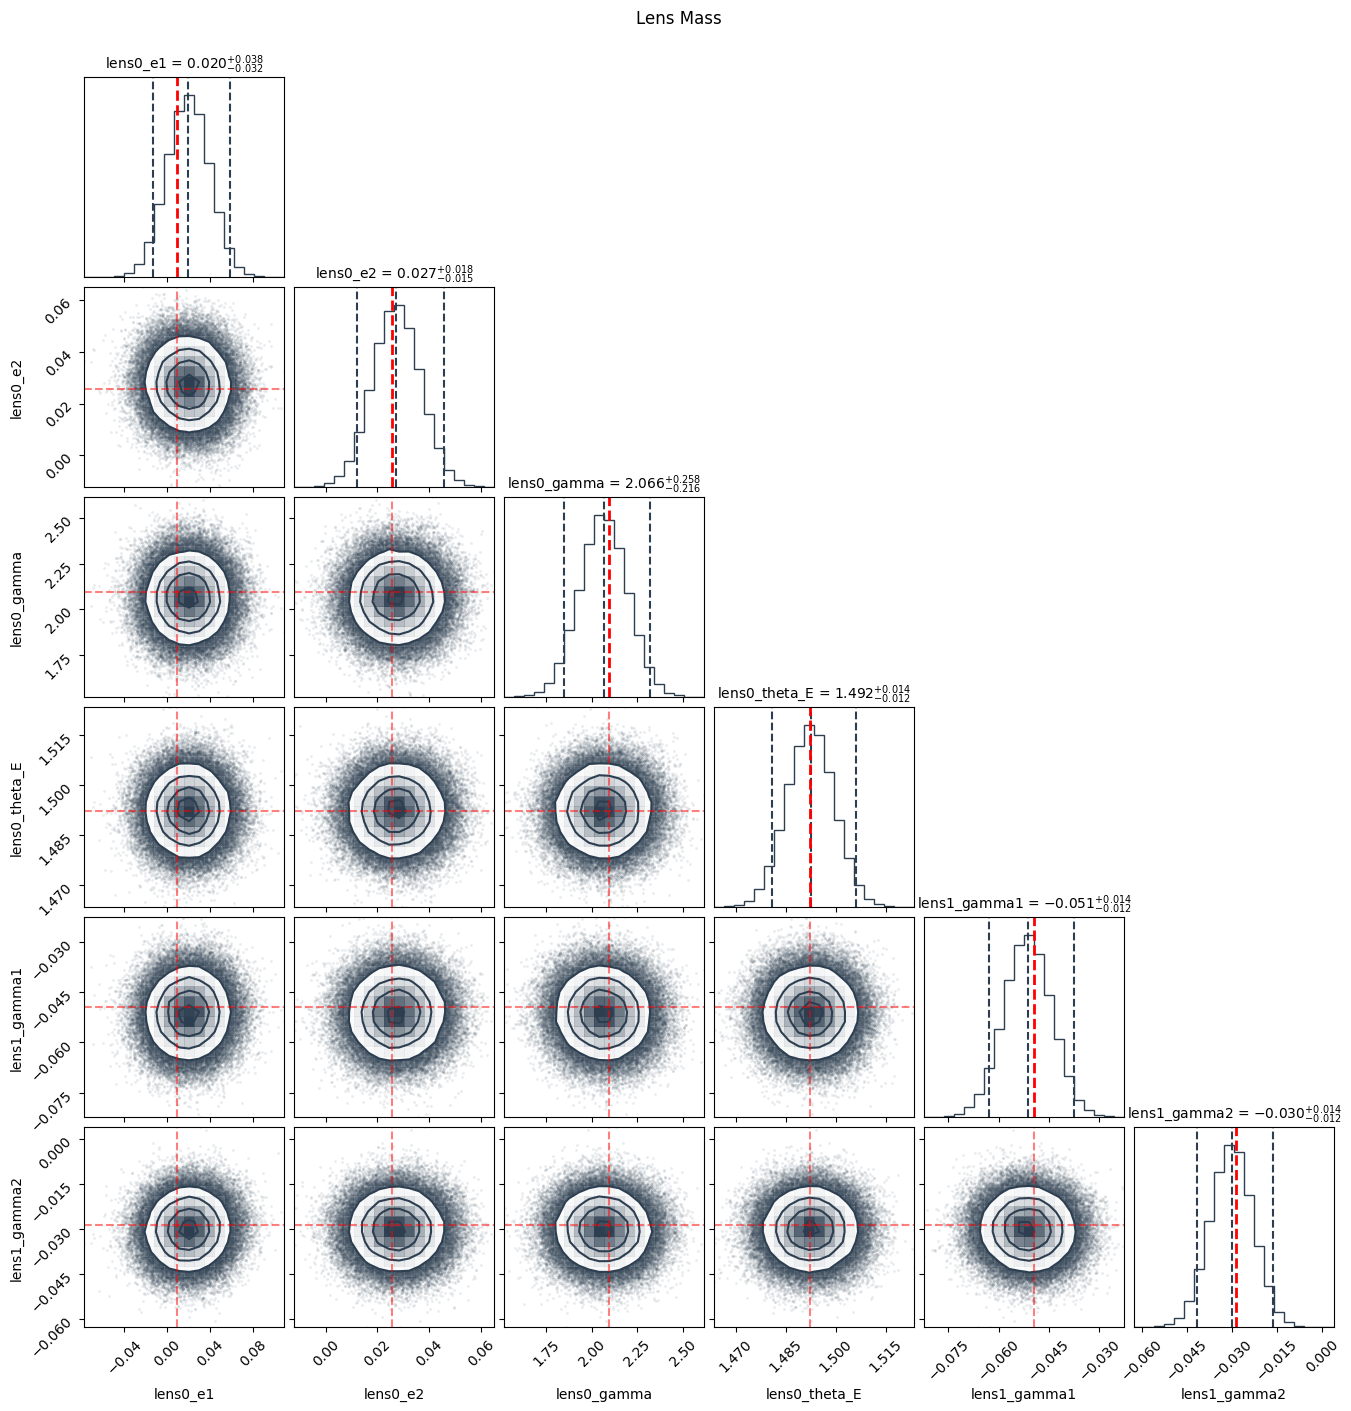

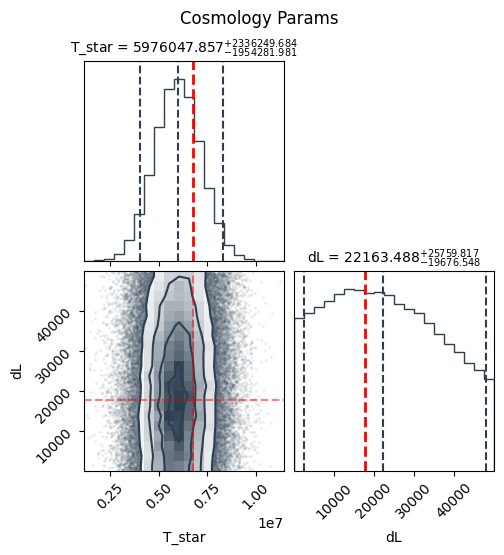

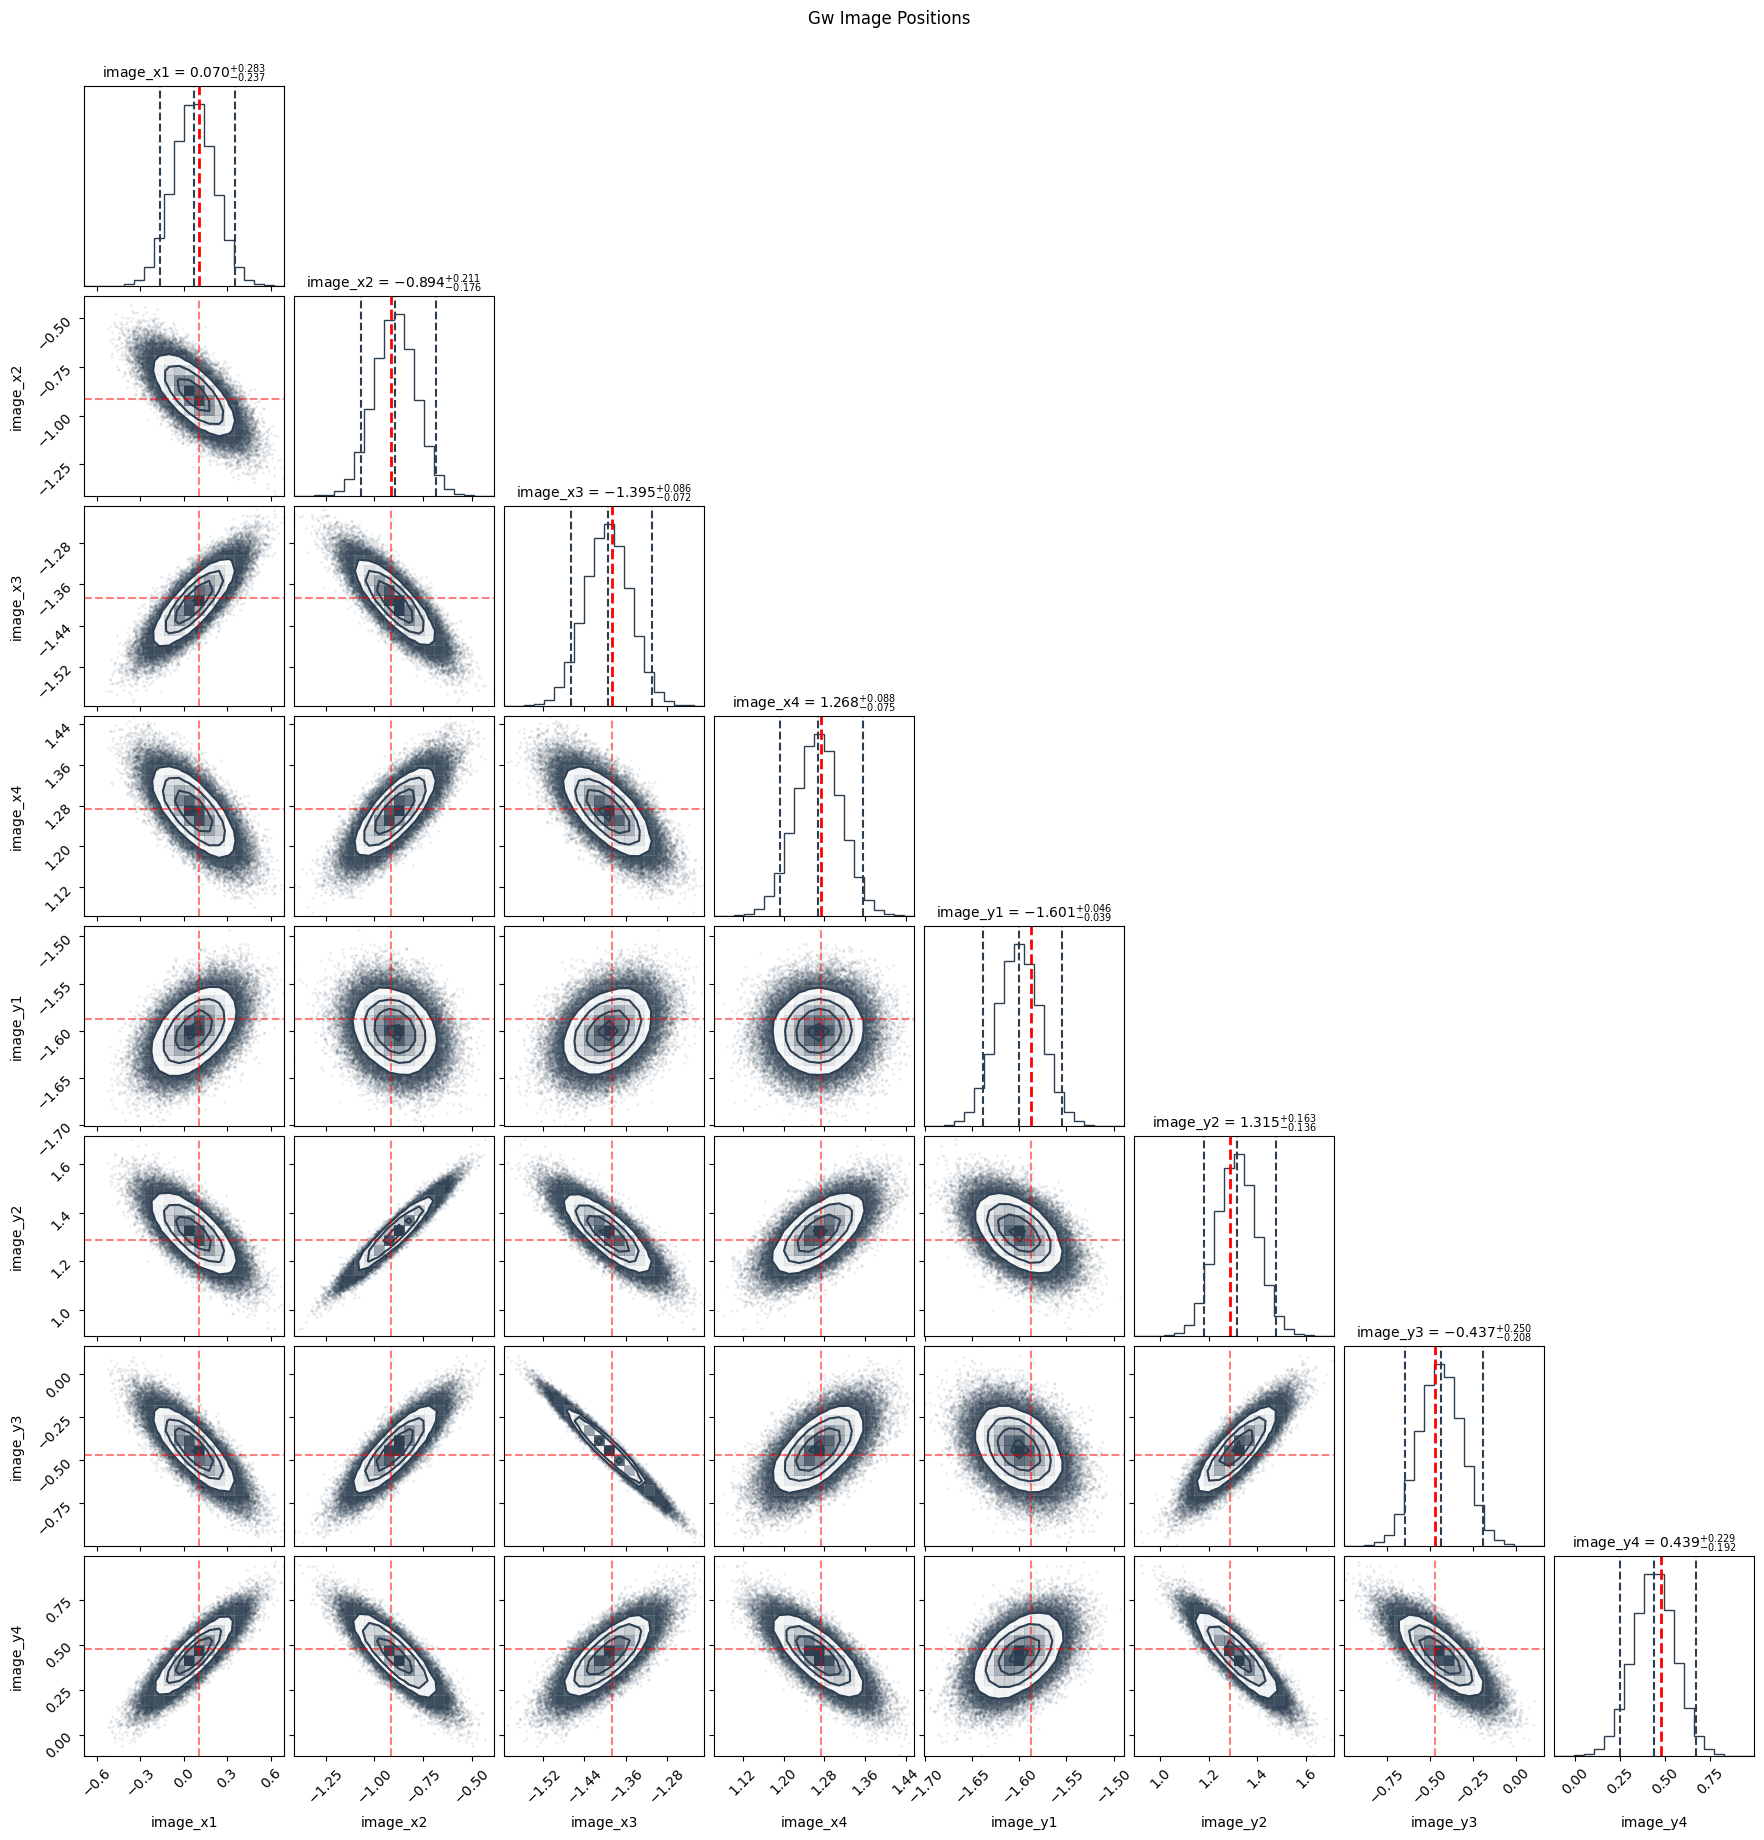

In [19]:
import corner

plot_posterior(
        samples_gw,
        truths_gw,
        cfg={
            "output": {"output_dir": None},
            "plot": {
               "plot_mode": "groupwise",
                "save_path": None,
            },
        },
    )

## Step 5 Construct the physical population priors

In [21]:
df = pd.read_csv('../../data_catalog/Qiuhan/Euclid_cats/filtered_lens_catalog_PL_IC_gt_70.csv')

In [22]:
list_of_lens_mass = []
for i in range(len(df)):
    row = df.iloc[i]
    lens_e1, lens_e2 = param_util.phi_q2_ellipticity(phi=row['deflector_pa'], q=row['deflector_q'])
    thetaE = float(row["deflector_thetaE"])
    gamma = float(row["deflector_slope"])
    gamma1 = float(row["deflector_shear1"])
    gamma2 = float(row["deflector_shear2"])
    pair = (i, lens_e1, lens_e2, thetaE, gamma, gamma1, gamma2)
    list_of_lens_mass.append(pair)

In [23]:
e1 = [item[1] for item in list_of_lens_mass]
e2 = [item[2] for item in list_of_lens_mass]
thetas = [item[3] for item in list_of_lens_mass]
gammas = [item[4] for item in list_of_lens_mass]
gamma1s = [item[5] for item in list_of_lens_mass]
gamma2s = [item[6] for item in list_of_lens_mass]

In [24]:
population = {'lens0_e1': e1, 'lens0_e2': e2, 'lens0_gamma': gammas, 'lens0_theta_E': thetas, 'lens1_gamma1': gamma1s, 'lens1_gamma2': gamma2s}

In [25]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

kde_e1 = gaussian_kde(e1)
kde_e2 = gaussian_kde(e2)
kde_thetaE = gaussian_kde(thetas)
kde_gamma = gaussian_kde(gammas)
kde_gamma1 = gaussian_kde(gamma1s)
kde_gamma2 = gaussian_kde(gamma2s)

In [26]:
population_kdes = {
    "lens0_e1": kde_e1,
    "lens0_e2": kde_e2,
    "lens0_gamma": kde_gamma,
    "lens0_theta_E": kde_thetaE,
    "lens1_gamma1": kde_gamma1,
    "lens1_gamma2": kde_gamma2
}

In [27]:
def log_population_prior(samples, population_kdes):

    log_p_pop = np.zeros(len(samples["lens0_gamma"]))

    for param, kde in population_kdes.items():

        x = np.asarray(samples[param])

        log_p_pop += kde.logpdf(x[np.newaxis, :])

    return log_p_pop

#### What about the population prior for the dL and T_star parameters?

## Step 6 Evaluate the GW prior-reweighting factor

$$w(\Lambda, \phi_\ell) = \frac{p(D_L \mid H_L) p(T_* \mid H_L) p(\phi_\ell \mid H_L)}{F_{\mathrm{GW}}(\Lambda, \phi_\ell)}.$$

In [28]:
lens_params = [
    "lens0_gamma",
    "lens0_theta_E",
    "lens0_e1",
    "lens0_e2",
    "lens1_gamma1",
    "lens1_gamma2"
]

required_gw_params = [
    "dL",
    "T_star"
] + lens_params

gw_sample_dict = {
    param: np.asarray(samples_gw[param])
    for param in required_gw_params
}

In [29]:
def log_F_GW(samples, tp, row):

    phi = np.deg2rad(row["deflector_pa"])

    sigma_e = (
        2 / (1 + row["deflector_q"])**2
    ) * 0.05

    sigma_e1 = abs(np.cos(2 * phi)) * sigma_e
    sigma_e2 = abs(np.sin(2 * phi)) * sigma_e

    log_F = np.zeros(len(samples["dL"]))

    log_F += uniform.logpdf(
        samples["dL"], loc=0.1, scale=50000.0 - 0.1
    )

    log_F += uniform.logpdf(
        samples["T_star"], loc=1e1, scale=1e12 - 1e1
    )

    log_F += norm.logpdf(
        samples["lens0_gamma"], loc=2.0, scale=0.2
    )

    log_F += norm.logpdf(
        samples["lens0_theta_E"],
        loc=tp["lens0_theta_E"],
        scale=0.01
    )

    log_F += norm.logpdf(
        samples["lens0_e1"],
        loc=tp["lens0_e1"],
        scale=sigma_e1
    )

    log_F += norm.logpdf(
        samples["lens0_e2"],
        loc=tp["lens0_e2"],
        scale=sigma_e2
    )

    log_F += norm.logpdf(
        samples["lens1_gamma1"],
        loc=tp["lens1_gamma1"],
        scale=0.01
    )

    log_F += norm.logpdf(
        samples["lens1_gamma2"],
        loc=tp["lens1_gamma2"],
        scale=0.01
    )

    return log_F

In [30]:
#log_p_dL = kde_dL_HL.logpdf(gw_sample_dict["dL"][np.newaxis, :])

#log_p_Tstar = kde_Tstar_HL.logpdf(gw_sample_dict["T_star"][np.newaxis, :])

log_p_population = log_population_prior(
    gw_sample_dict,
    population_kdes
)

log_F_gw = log_F_GW(
    gw_sample_dict,
    tp_gw,
    gw_row
)

log_w = (
    #log_p_dL
    #+ log_p_Tstar
    + log_p_population
    - log_F_gw
)

In [31]:
log_w

array([25.9021014 , 26.76017407, 27.44439737, ..., 26.57515247,
       26.3406298 , 25.43651306], shape=(116000,))

In [35]:
print("NaNs:", np.isnan(log_w).sum())
print("+inf:", np.isposinf(log_w).sum())
print("-inf:", np.isneginf(log_w).sum())

print("Mean:", np.mean(log_w))
print("Median:", np.median(log_w))
print("Std:", np.std(log_w))
print("Min:", np.min(log_w))
print("Max:", np.max(log_w))

NaNs: 0
+inf: 0
-inf: 0
Mean: 26.781938314134315
Median: 26.41349890626128
Std: 1.367897017814178
Min: 25.02161591139118
Max: 45.26398130312562


## Step 7 Evaluate the EM contribution for each catalogue candidate
$$A_i(\phi_\ell) = Z_{\mathrm{EM},i}^{\mathrm{fid}} \frac{p(\phi_\ell \mid d_{\mathrm{EM}}^i)}{F_{i,\mathrm{EM}}(\phi_\ell)}$$

In [36]:
def log_F_EM(samples, tp, row):

    phi = np.deg2rad(row["deflector_pa"])

    sigma_e = (
        2 / (1 + row["deflector_q"])**2
    ) * 0.05

    sigma_e1 = abs(np.cos(2 * phi)) * sigma_e
    sigma_e2 = abs(np.sin(2 * phi)) * sigma_e

    log_F = np.zeros(len(samples["lens0_gamma"]))

    log_F += norm.logpdf(
        samples["lens0_gamma"],
        loc=2.0,
        scale=0.2
    )

    log_F += norm.logpdf(
        samples["lens0_theta_E"],
        loc=tp["lens0_theta_E"],
        scale=0.01
    )

    log_F += norm.logpdf(
        samples["lens0_e1"],
        loc=0.0,
        scale=sigma_e1
    )

    log_F += norm.logpdf(
        samples["lens0_e2"],
        loc=0.0,
        scale=sigma_e2
    )

    log_F += norm.logpdf(
        samples["lens1_gamma1"],
        loc=tp["lens1_gamma1"],
        scale=0.01
    )

    log_F += norm.logpdf(
        samples["lens1_gamma2"],
        loc=tp["lens1_gamma2"],
        scale=0.01
    )

    return log_F

In [37]:
from scipy.stats import norm, uniform
from scipy.special import logsumexp

# Six lens parameters used in the population and EM KDEs

lens_params = [
    "lens0_gamma",
    "lens0_theta_E",
    "lens0_e1",
    "lens0_e2",
    "lens1_gamma1",
    "lens1_gamma2",
]

# The order MUST match the order used when fitting each EM KDE.
em_kde_params = lens_params.copy()

# GW posterior samples
samples_matrix_GW = np.vstack([
    gw_sample_dict[param]
    for param in em_kde_params
])

log_A_list = []

for idx, result in em_results.items():

    # EM posterior density evaluated at GW samples
    log_p_em = result["kde"].logpdf(
        samples_matrix_GW
    )

    # EM fiducial prior evaluated at GW samples
    log_F_em = log_F_EM(
        gw_sample_dict,
        result["truth_params"],
        result["row"]
    )

    # Candidate-specific EM contribution
    log_A_i = (
        result["logZ"]
        + log_p_em
        - log_F_em
    )

    log_A_list.append(log_A_i)

In [38]:
log_A_matrix = np.asarray(log_A_list)

print("Shape:", log_A_matrix.shape)

Shape: (3, 116000)


In [39]:
log_catalogue_term = (
    logsumexp(log_A_matrix, axis=0)
    - np.log(len(em_results))
)

## Step 8 include catalogue completeness
$$B(\phi_\ell) = \frac{f}{N_{\mathrm{cat}}} \sum_{i=1}^{N_{\mathrm{cat}}} A_i(\phi_\ell) + (1 - f).$$

In [40]:
#set the catalogue completeness
f = 1

In [41]:
if f == 1.0:
    log_B = log_catalogue_term
elif f == 0.0:
    log_B = np.zeros_like(log_catalogue_term)

else:
    log_B = np.logaddexp(
        np.log(f) + log_catalogue_term,
        np.log1p(-f)
    )

In [42]:
log_B

array([3773.07503382, 3787.24425493, 3966.26252085, ..., 4450.04689406,
       4131.25802991, 4420.49360099], shape=(116000,))

## Step 9 - calculate the final MM improvement!

$$\frac{Z_L^{\mathrm{MM}}}{Z_L} = \frac{\langle B(\phi_\ell) w(\Lambda, \phi_\ell) \rangle_{\mathrm{GW}}}{\langle w(\Lambda, \phi_\ell) \rangle_{\mathrm{GW}}}$$

In [43]:
log_numerator = logsumexp(
    log_B + log_w
)

log_denominator = logsumexp(
    log_w
)

log_gain = log_numerator - log_denominator

gain = np.exp(log_gain)

print("Log evidence improvement:", log_gain)
print("Evidence improvement:", gain)

Log evidence improvement: 4459.932490036633
Evidence improvement: inf


/var/folders/9s/6gn9tn517t98f_24r73rxxn40000gn/T/ipykernel_15546/3626363406.py:11: RuntimeWarning: overflow encountered in exp
  gain = np.exp(log_gain)


In [44]:
print("Number of GW samples:", len(log_w))
print("Number of EM candidates:", len(em_results))

print("\nGW log-weight range:")
print(np.min(log_w), np.max(log_w))

print("\nCatalogue log-term range:")
print(np.min(log_catalogue_term), np.max(log_catalogue_term))

print("\nFinal log gain:", log_gain)
print("Final gain:", gain)

Number of GW samples: 116000
Number of EM candidates: 3

GW log-weight range:
25.02161591139118 45.26398130312562

Catalogue log-term range:
-12918.37215308391 4476.473742940892

Final log gain: 4459.932490036633
Final gain: inf


## Looking for whats the trouble

In [41]:
for name, arr in {
    "log_w": log_w,
    "log_B": log_B,
    "log_B + log_w": log_B + log_w
}.items():

    arr = np.asarray(arr)

    print(f"\n{name}")
    print("NaNs:", np.isnan(arr).sum())
    print("+inf:", np.isposinf(arr).sum())
    print("-inf:", np.isneginf(arr).sum())
    print("Min:", np.nanmin(arr))
    print("Max:", np.nanmax(arr))


log_w
NaNs: 0
+inf: 29
-inf: 0
Min: 25.032196240713773
Max: inf

log_B
NaNs: 0
+inf: 0
-inf: 0
Min: -10320.75375163215
Max: 4476.337830012982

log_B + log_w
NaNs: 0
+inf: 29
-inf: 0
Min: -10290.345086157342
Max: inf


In [42]:
log_numerator = logsumexp(log_B + log_w)
log_denominator = logsumexp(log_w)

print("log_numerator:", log_numerator)
print("log_denominator:", log_denominator)

log_numerator: inf
log_denominator: inf


In [43]:
print("log_w range:", np.min(log_w), np.max(log_w))

print("log_B range:", np.min(log_B), np.max(log_B))

print("log_A_matrix range:",
      np.min(log_A_matrix), np.max(log_A_matrix))

log_w range: 25.032196240713773 inf
log_B range: -10320.75375163215 4476.337830012982
log_A_matrix range: -2401096.366588699 4477.43644230165


In [44]:
# Find the indices where log_w is infinite
inf_idx = np.where(np.isposinf(log_w))[0]

print("Indices with +inf:", inf_idx)

# Inspect the corresponding values
for i in inf_idx[:10]:

    print(f"\nGW sample {i}")

    print("log_p_population:", log_p_population[i])
    print("log_F_gw:", log_F_gw[i])
    print("log_w:", log_w[i])

Indices with +inf: [ 10831  10834  27827  30498  32530  32570  35179  36221  36983  37326
  37464  38908  46905  53910  55604  55605  55606  63212  63213  66112
  66436  71193  75214  76138  90187  98542 103775 106122 106243]

GW sample 10831
log_p_population: 4.023307676419127
log_F_gw: -inf
log_w: inf

GW sample 10834
log_p_population: 4.074586471289009
log_F_gw: -inf
log_w: inf

GW sample 27827
log_p_population: 4.0680558508229
log_F_gw: -inf
log_w: inf

GW sample 30498
log_p_population: 4.268794884546163
log_F_gw: -inf
log_w: inf

GW sample 32530
log_p_population: 4.270098426017011
log_F_gw: -inf
log_w: inf

GW sample 32570
log_p_population: 4.4933877000077755
log_F_gw: -inf
log_w: inf

GW sample 35179
log_p_population: 4.194288563644125
log_F_gw: -inf
log_w: inf

GW sample 36221
log_p_population: 4.083667137523251
log_F_gw: -inf
log_w: inf

GW sample 36983
log_p_population: 3.9635381357857877
log_F_gw: -inf
log_w: inf

GW sample 37326
log_p_population: 4.065859616333897
log_F_gw: 

In [45]:
phi_gw = np.deg2rad(gw_row["deflector_pa"])

sigma_e = (
    2 / (1 + gw_row["deflector_q"])**2
) * 0.05

sigma_e1_gw = abs(np.cos(2 * phi_gw)) * sigma_e
sigma_e2_gw = abs(np.sin(2 * phi_gw)) * sigma_e

print("sigma_e:", sigma_e)
print("sigma_e1_gw:", sigma_e1_gw)
print("sigma_e2_gw:", sigma_e2_gw)

sigma_e: 0.026390838950433888
sigma_e1_gw: 0.016306495173375565
sigma_e2_gw: 0.02075029145984263


In [46]:
print("log_F_gw:")
print("NaNs:", np.isnan(log_F_gw).sum())
print("+inf:", np.isposinf(log_F_gw).sum())
print("-inf:", np.isneginf(log_F_gw).sum())

print("\nlog_p_population:")
print("NaNs:", np.isnan(log_p_population).sum())
print("+inf:", np.isposinf(log_p_population).sum())
print("-inf:", np.isneginf(log_p_population).sum())

log_F_gw:
NaNs: 0
+inf: 0
-inf: 29

log_p_population:
NaNs: 0
+inf: 0
-inf: 0


In [31]:
phi_gw = np.deg2rad(gw_row["deflector_pa"])

sigma_e = (
    2 / (1 + gw_row["deflector_q"])**2
) * 0.05

sigma_e1_gw = abs(np.cos(2 * phi_gw)) * sigma_e
sigma_e2_gw = abs(np.sin(2 * phi_gw)) * sigma_e

prior_terms = {
    "dL": uniform.logpdf(
        gw_sample_dict["dL"],
        loc=10.0,
        scale=50000.0 - 10.0
    ),

    "T_star": uniform.logpdf(
        gw_sample_dict["T_star"],
        loc=1e1,
        scale=1e12 - 1e1
    ),

    "gamma": norm.logpdf(
        gw_sample_dict["lens0_gamma"],
        loc=2.0,
        scale=0.2
    ),

    "theta_E": norm.logpdf(
        gw_sample_dict["lens0_theta_E"],
        loc=tp_gw["lens0_theta_E"],
        scale=0.01
    ),

    "e1": norm.logpdf(
        gw_sample_dict["lens0_e1"],
        loc=tp_gw["lens0_e1"],
        scale=sigma_e1_gw
    ),

    "e2": norm.logpdf(
        gw_sample_dict["lens0_e2"],
        loc=tp_gw["lens0_e2"],
        scale=sigma_e2_gw
    ),

    "gamma1": norm.logpdf(
        gw_sample_dict["lens1_gamma1"],
        loc=tp_gw["lens1_gamma1"],
        scale=0.01
    ),

    "gamma2": norm.logpdf(
        gw_sample_dict["lens1_gamma2"],
        loc=tp_gw["lens1_gamma2"],
        scale=0.01
    )
}

for name, values in prior_terms.items():

    print(
        f"{name:10s} | "
        f"-inf: {np.isneginf(values).sum():6d} | "
        f"NaN: {np.isnan(values).sum():6d}"
    )

dL         | -inf:     19 | NaN:      0
T_star     | -inf:      0 | NaN:      0
gamma      | -inf:      0 | NaN:      0
theta_E    | -inf:      0 | NaN:      0
e1         | -inf:      0 | NaN:      0
e2         | -inf:      0 | NaN:      0
gamma1     | -inf:      0 | NaN:      0
gamma2     | -inf:      0 | NaN:      0


In [32]:
for param in ["dL", "T_star"]:

    x = gw_sample_dict[param]

    print(f"\n{param}")
    print("Minimum:", np.min(x))
    print("Maximum:", np.max(x))


dL
Minimum: 1.0370746800339203
Maximum: 49999.92345608539

T_star
Minimum: 1141506.7932073441
Maximum: 11467430.383786822


In [33]:
ctx_gw["cfg"]["priors"].keys()

dict_keys(['dL', 'lens0_gamma', 'lens0_theta_E', 'lens0_e1', 'lens0_e2', 'lens0_center_x', 'lens0_center_y', 'lens1_gamma1', 'lens1_gamma2', 'lens1_ra_0', 'lens1_dec_0', 'light0_R_sersic', 'light0_n_sersic', 'light0_amp', 'light0_e1', 'light0_e2', 'light0_center_x', 'light0_center_y', 'noise_sigma_bkg', 'source0_n_sersic'])

In [34]:
dL = np.asarray(gw_sample_dict["dL"])

outside = dL < 10

print("Number outside prior:", outside.sum())
print("Smallest values:", np.sort(dL)[:20])
print("Largest values outside prior:", dL[outside].max())

Number outside prior: 19
Smallest values: [ 1.03707468  1.23265489  1.51459693  2.8528884   2.9507063   3.10441229
  3.36292972  3.66030286  4.79553209  5.3967567   5.47029356  5.57668534
  5.71341692  6.88043412  6.92428492  8.29417585  9.52732832  9.88406059
  9.89340759 10.48195625]
Largest values outside prior: 9.89340758622331
